In [1]:
from utils import *
NOTEBOOK_ID = '03'

In [2]:
library_df = pd.read_csv(f'{LIBRARY_DIR}/viral_library.csv')
tile_df = pd.read_csv(f'{TILE_DIR}/viral_tiles.csv')

library_df['encoding'] = library_df['aa_seq'].apply(lambda x: one_hot_encode_protein(x))
SELECT_SEQUENCES = False
if SELECT_SEQUENCES:
    num_seqs = 205
    if not os.path.isfile(f'../outputs/X_{num_seqs}.pkl'):
        X, idx = select_maximally_different_arrays(np.stack(library_df['encoding']),num_seqs)
        with open(f'idx_{num_seqs}.txt', 'w') as file:
            for i in idx:
                file.write(f"{i}\n")
        pd.DataFrame(X).to_pickle(f'X_{num_seqs}.pkl')   
    X = np.stack(library_df['encoding'])
    maximized_sequences = pd.read_pickle(f'../outputs/X_{num_seqs}.pkl').to_numpy()
    indicies = []
    for j in range(maximized_sequences.shape[0]):
        indicies.append(find_row_in_matrix(X, maximized_sequences[j,:])[0])
    indicies = sorted(indicies)
    selected_df = library_df.loc[indicies]
    remaining_df = library_df[~library_df.index.isin(indicies)]

In [3]:
out_file = f'{LIBRARY_DIR}/viral_controls.csv'
if not os.path.isfile(out_file):
    controls_df = pd.concat([
    pd.read_csv(f'{METADATA_DIR}/controls/validated_virus_tiles-1.csv',sep=';')[['gBlockname','DNA']].rename(columns={'gBlockname':'tile_ID','DNA':'na_seq'}),
    pd.read_csv(f'{METADATA_DIR}/controls/activator_tile_sequences.csv',sep=';')[['Tile ID','Sequence']].rename(columns={'Tile ID':'tile_ID','Sequence':'na_seq'})
    ]).reset_index(drop=True)
    controls_df.loc[25,'na_seq'] = 'GGCTCTGGCTCTGGTTCCGGCTCTGGTTCCGGCTCTGGTCCGAAAAACCTCGAGTTCTATTTCATTTCAGCTATCAGTGACTGACTGATCGAGTGAGATTTGCATATGACTGACATTCCATTGCATATTTCAACCAATCAGCGGTCACGGCGGCGGAGA'
    controls_df.loc[36,'na_seq'] = 'GGTTCCGGCTCCGGCTCCTCTGAGAAGAACAGAATGATTGTACCCCAAGAAACACAGACATCAACGCTTTTCACTGAGGATCAGAGCTTTTGGGAAAATCTATTCAAGGATTTTAATAACGAAAACCTTGAGGTTCCACTTCAAGATCATTCCTCAACC'
    controls_df.loc[27,'na_seq'] = 'GAGAATGTAGTTTTCATTACTTCCACGGCTGGGCAAGGTGAATTCCCCCAAGACGGTAAGTCTTTCTGGGAAGCTCTGAAAAATGACACCGACTTGGATTTAGCTAGTTTGAATGTTGCTGTTTTTGGCCTCGGTGATTCTGAGTATTGGCCACGTAAA'
    controls_df['na_seq'] = controls_df['na_seq'].apply(lambda x: remove_sites(x))
    controls_df['tile'] = controls_df['na_seq'].apply(lambda x: str(Seq(x).translate()))
    controls_df.to_csv(out_file,index=False)
else:
    controls_df = pd.read_csv(out_file)
controls_df.head()

,tile_ID,na_seq,tile
0,AL2-1,ATGCGTAACAGCAGCTCCTCAACACCTCCGAGCATCAAGGCTCAAC...,MRNSSSSTPPSIKAQHRAAKRRAIRRRRIDLNCGCSIYIHIDCRNN...
1,AL2-2,AGTATCTACATCCATATCGACTGCCGAAACAACGGGTTCACTCATA...,SIYIHIDCRNNGFTHRGTYHCASSREWRLYLGDNKSPLFQDNQRRG...
2,AL2-3,AATCAACGACGTGGAAGCCCTTTACACCAGCACCAAGATATCCCGC...,NQRRGSPLHQHQDIPLTNQVQPQPEESIGSPQGISQLPSMDDIDDS...
3,P12-1,ATGGACGTGATCGTGAAGATGTTGATCCTGCGTAAATTCGTCGAAC...,MDVIVKMLILRKFVEQGNVCPIHLCVDIYKRAFPRSVNKGRSSYAR...
4,P12-2,AGGTGCCACCGATGTTATAGAGTATATCCCCCTTTGTTCCCTGAGA...,RCHRCYRVYPPLFPEISRCDNRTCVPGISYNSKVRDYILWGVTEVI...


In [4]:
out_file = f'{LIBRARY_DIR}/eLW044-fLW134_twist_order.csv'
if not os.path.isfile(out_file):
    lib_500_df = pd.concat([
        selected_df,
        remaining_df.nlargest(250,'PADDLE_zscore'),
        pd.concat([controls_df]*1,ignore_index=True)
        ])[['tile_ID','na_seq']].reset_index(drop=True)
    lib_500_df['library_ID'] = [f'eLW044-fLW134-{str(i+1).zfill(3)}' for i in lib_500_df.index]
    lib_500_df['na_seq+overhangs'] = lib_500_df['na_seq'].apply(lambda x: 'ACGTCAGtgtGGTCTCtaggt'.upper()+x.lower()+'TAAgcttagagaccaagcgctta'.upper())
    lib_500_df = lib_500_df[['library_ID','tile_ID','na_seq','na_seq+overhangs']]
    lib_500_df.to_csv(out_file,index=False)
else:
    lib_500_df = pd.read_csv(out_file)
lib_500_df.head()

,library_ID,tile_ID,na_seq,na_seq+overhangs
0,eLW044-fLW134-001,CKM63_gp4-016,GAAATTCTTGATGATAATGATGCTCTTTTTTCTGAACATGATCTTT...,ACGTCAGTGTGGTCTCTAGGTgaaattcttgatgataatgatgctc...
1,eLW044-fLW134-002,SPCV_gp1-074,ATTGGTCATATTTCTCCAAATTGTAAGAAGCCAAAGAAGTCTAATA...,ACGTCAGTGTGGTCTCTAGGTattggtcatatttctccaaattgta...
2,eLW044-fLW134-003,SPCV_gp1-073,AAGCCATGTACTTGTTATAATTGTGGTGAAATTGGTCATATTTCTC...,ACGTCAGTGTGGTCTCTAGGTaagccatgtacttgttataattgtg...
3,eLW044-fLW134-004,SPCV_gp2-013,TATCCAAGAAAGAAGGTTCTTATTCCATGGGAAAAGGGTAATCCAT...,ACGTCAGTGTGGTCTCTAGGTtatccaagaaagaaggttcttattc...
4,eLW044-fLW134-005,Grslavgp1-310,AATAGAGATTTTGCTTCTGTTGTTTCTAATATGCTTGGTGATGATG...,ACGTCAGTGTGGTCTCTAGGTaatagagattttgcttctgttgttt...


In [5]:
out_file = f'{LIBRARY_DIR}/eLW044-fLW135_twist_order.csv'
if not os.path.isfile(out_file):
    lib_1000_df = pd.concat([
        selected_df,
        remaining_df.nlargest(705,'PADDLE_zscore'),
        pd.concat([controls_df]*2,ignore_index=True)
        ])[['tile_ID','na_seq']].reset_index(drop=True)
    lib_1000_df['library_ID'] = [f'eLW044-fLW135-{str(i+1).zfill(3)}' for i in lib_1000_df.index]
    lib_1000_df['na_seq+overhangs'] = lib_1000_df['na_seq'].apply(lambda x: 'ACGTCAGtgtGGTCTCtaggt'.upper()+x.lower()+'TAAgcttagagaccaagcgctta'.upper())
    lib_1000_df = lib_1000_df[['library_ID','tile_ID','na_seq','na_seq+overhangs']]
    lib_1000_df.to_csv(out_file,index=False)
else:
    lib_1000_df = pd.read_csv(out_file)
lib_1000_df.head()

,library_ID,tile_ID,na_seq,na_seq+overhangs
0,eLW044-fLW135-001,CKM63_gp4-016,GAAATTCTTGATGATAATGATGCTCTTTTTTCTGAACATGATCTTT...,ACGTCAGTGTGGTCTCTAGGTgaaattcttgatgataatgatgctc...
1,eLW044-fLW135-002,SPCV_gp1-074,ATTGGTCATATTTCTCCAAATTGTAAGAAGCCAAAGAAGTCTAATA...,ACGTCAGTGTGGTCTCTAGGTattggtcatatttctccaaattgta...
2,eLW044-fLW135-003,SPCV_gp1-073,AAGCCATGTACTTGTTATAATTGTGGTGAAATTGGTCATATTTCTC...,ACGTCAGTGTGGTCTCTAGGTaagccatgtacttgttataattgtg...
3,eLW044-fLW135-004,SPCV_gp2-013,TATCCAAGAAAGAAGGTTCTTATTCCATGGGAAAAGGGTAATCCAT...,ACGTCAGTGTGGTCTCTAGGTtatccaagaaagaaggttcttattc...
4,eLW044-fLW135-005,Grslavgp1-310,AATAGAGATTTTGCTTCTGTTGTTTCTAATATGCTTGGTGATGATG...,ACGTCAGTGTGGTCTCTAGGTaatagagattttgcttctgttgttt...


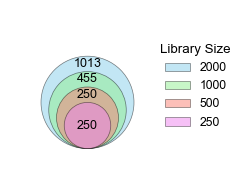

In [6]:
lib_250 = set(pd.read_csv(f'{LIBRARY_DIR}/eLW044-fLW133_twist_order.csv')['na_seq+overhangs'])
lib_500 = set(lib_500_df['na_seq+overhangs'])
lib_1000 = set(lib_1000_df['na_seq+overhangs'])
lib_2000 = set(pd.read_csv(f'{LIBRARY_DIR}/eLW044-fLW132_twist_order.csv')['na_seq+overhangs'])

fig, ax = plt.subplots(figsize=(2, 2))
colors = ['skyblue', 'lightgreen', 'salmon', 'violet']
circle1 = plt.Circle((0.5, 0.4), 0.3, facecolor=colors[0], alpha=0.5, label="2000",edgecolor='black',linewidth=0.5)
circle2 = plt.Circle((0.5, 0.35), 0.25, facecolor=colors[1], alpha=0.5, label="1000",edgecolor='black',linewidth=0.5)
circle3 = plt.Circle((0.5, 0.3), 0.20, facecolor=colors[2], alpha=0.5, label="500",edgecolor='black',linewidth=0.5)
circle4 = plt.Circle((0.5, 0.25), 0.15, facecolor=colors[3], alpha=0.5, label="250",edgecolor='black',linewidth=0.5)
text1 = plt.text(x=0.5, y=0.65, s='1013',horizontalalignment='center',verticalalignment='center')
text2 = plt.text(x=0.5, y=0.55, s='455',horizontalalignment='center',verticalalignment='center')
text3 = plt.text(x=0.5, y=0.45, s='250',horizontalalignment='center',verticalalignment='center')
text4 = plt.text(x=0.5, y=0.25, s='250',horizontalalignment='center',verticalalignment='center')
ax.add_patch(circle1)
ax.add_patch(circle2)
ax.add_patch(circle3)
ax.add_patch(circle4)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_yticks([])
ax.axis('off')
plt.legend(bbox_to_anchor=(0.9,0.85),title='Library Size',frameon=False,alignment='center')

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-nested_libraries.svg',**FIG_PARAMS)

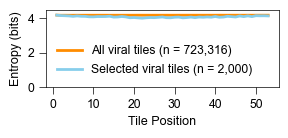

In [9]:
df = pd.DataFrame(calculate_entropy_from_fasta(f"{TILE_DIR}/viral_tiles.faa"),columns=['entropy'])
df.index += 1
plt.figure(figsize=(3,1))
g = sns.lineplot(data=df.reset_index(),x='index',y="entropy",color='darkorange',linewidth=2,label='All viral tiles (n = 723,316)')
df2 = pd.DataFrame(calculate_entropy_from_fasta(f"{LIBRARY_DIR}/viral_library.faa"),columns=['entropy'])
df2.index += 1
g = sns.lineplot(data=df2.reset_index(),x='index',y="entropy",color='skyblue',linewidth=2,label='Selected viral tiles (n = 2,000)')
g.set(xlabel='Tile Position',ylabel='Entropy (bits)',ylim=(0,4.5));
g.legend(frameon=False)

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-library_entropy.svg',**FIG_PARAMS)

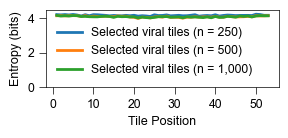

In [11]:
lib_250_df = pd.read_csv(f'{LIBRARY_DIR}/eLW044-fLW133.csv')
lib_250_df['aa_seq'] = lib_250_df['na_seq'].apply(lambda x: str(Seq(x).translate()))
lib_500_df = pd.read_csv(f'{LIBRARY_DIR}/eLW044-fLW134_twist_order.csv')
lib_500_df['aa_seq'] = lib_500_df['na_seq'].apply(lambda x: str(Seq(x).translate()))
lib_1k_df = pd.read_csv(f'{LIBRARY_DIR}/eLW044-fLW135_twist_order.csv')
lib_1k_df['aa_seq'] = lib_1k_df['na_seq'].apply(lambda x: str(Seq(x).translate()))

plt.figure(figsize=(3,1))
df3 = pd.DataFrame(entropy_from_dataframe(lib_250_df, "aa_seq"),columns=['entropy'])
df3.index += 1
g = sns.lineplot(data=df3.reset_index(),x='index',y="entropy",linewidth=2,label='Selected viral tiles (n = 250)')
df3 = pd.DataFrame(entropy_from_dataframe(lib_500_df, "aa_seq"),columns=['entropy'])
df3.index += 1
g = sns.lineplot(data=df3.reset_index(),x='index',y="entropy",linewidth=2,label='Selected viral tiles (n = 500)')
df3 = pd.DataFrame(entropy_from_dataframe(lib_1k_df, "aa_seq"),columns=['entropy'])
df3.index += 1
g = sns.lineplot(data=df3.reset_index(),x='index',y="entropy",linewidth=2,label='Selected viral tiles (n = 1,000)')
g.set(xlabel='Tile Position',ylabel='Entropy (bits)',ylim=(0,4.5));
g.legend(frameon=False)

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-sublibrary_entropy.svg',**FIG_PARAMS)